In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# **Loss = Mean Absolute Error**

In [112]:
class LinearRegression_MAE:
  def __init__(self, lr=0.001, epochs=1000):
    self.lr = lr
    self.epochs = epochs
    self.w = None
    self.b = None
    self.Losses = []
  def predict(self,x):
    return self.b + x@self.w
  def compute_loss(self,y_pred,y):
    return np.abs(y_pred-y)
  def dL_dw(self,x,y_pred,y):
    return  x*(y_pred-y)/ np.abs((y_pred-y)+1e-5)
  def dL_db(self,y_pred,y):
    return (y_pred-y)/ np.abs((y_pred-y)+1e-5)

  def fit(self,X,y):
    n_samples, n_features = X.shape
    rd = np.random.uniform(-1,1,size=n_features+1)
    self.b, self.w = rd[0], rd[1:]
    for epoch in range(self.epochs):
      Loss = []
      for i in range(n_samples):
        x_train, y_train = X[i], y[i]
        y_pred = self.predict(x_train)
        loss = self.compute_loss(y_pred,y_train)
        Loss.append(loss)
        dL_dw = self.dL_dw(x_train,y_pred,y_train)
        dL_db = self.dL_db(y_pred,y_train)
        self.w -= self.lr*dL_dw
        self.b -= self.lr*dL_db
      self.Losses.append(np.mean(Loss))
      print(f"Epoch: {epoch+1:<10}======== Loss: {self.Losses[-1]:<30} ============ w= {str(self.w):<20} ======= b= {str(self.b):<10}")

In [113]:
df = pd.DataFrame({
    'areas':[6.7, 4.6, 3.5, 5.5],
    'prices': [9.1, 5.9, 4.6, 6.7]
})
df

,areas,prices
0,6.7,9.1
1,4.6,5.9
2,3.5,4.6
3,5.5,6.7


In [114]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [115]:
rg = LinearRegression_MAE(lr=0.01, epochs= 500)

In [116]:
rg.fit(X,y)

Epoch: 1         ======== Loss: 10.733149720039451             ============ w= [-0.6561311]         ======= b= -0.1524837411383206
Epoch: 2         ======== Loss: 9.662923678473494              ============ w= [-0.45313088]        ======= b= -0.11248369691300278
Epoch: 3         ======== Loss: 8.592697515425142              ============ w= [-0.25013065]        ======= b= -0.07248364707535393
Epoch: 4         ======== Loss: 7.522471198687295              ============ w= [-0.04713037]        ======= b= -0.032483589987296314
Epoch: 5         ======== Loss: 6.452244681211384              ============ w= [0.15586995]         ======= b= 0.007516476833451925
Epoch: 6         ======== Loss: 5.382017890257967              ============ w= [0.35887033]         ======= b= 0.047516557419055416
Epoch: 7         ======== Loss: 4.311790704292802              ============ w= [0.56187082]         ======= b= 0.08751665900006765
Epoch: 8         ======== Loss: 3.241562895819733              ============ w

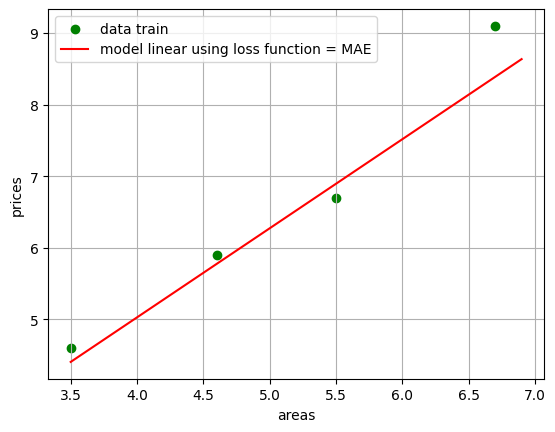

In [117]:
# Vẽ mô hình sau khi đã huấn luyện với Loss =  MAE
plt.scatter(X.flatten(),y,c='g',label = 'data train')
# Tạo dữ liệu để vẽ đường thẳng
x_plot = np.arange(3.5,7,0.1)
y_plot = rg.b + rg.w*x_plot
plt.plot(x_plot,y_plot,c='r',label = 'model linear using loss function = MAE')
plt.legend()
plt.grid()
plt.xlabel('areas')
plt.ylabel('prices')
plt.show()

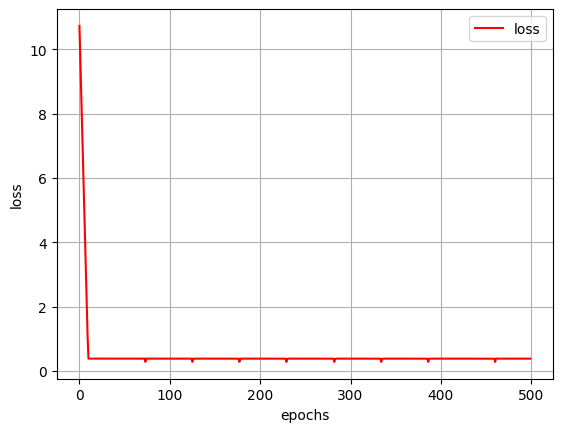

In [118]:
# Vẽ Loss của mô hình trong quá trình huấn luyện
plt.plot(rg.Losses,c='r',label = 'loss')
plt.legend()
plt.grid()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

# **Huber Loss**

1. **So sánh Loss MAE với MSE khi data có nhiễu**

In [119]:
data_noise = pd.DataFrame({
    'areas':[7.9, 4.6, 3.5, 5.5, 6.7],
    'prices': [9.3, 5.9, 4.6, 6.6, 10.1]
})
data_noise

,areas,prices
0,7.9,9.3
1,4.6,5.9
2,3.5,4.6
3,5.5,6.6
4,6.7,10.1


Text(0, 0.5, 'prices')

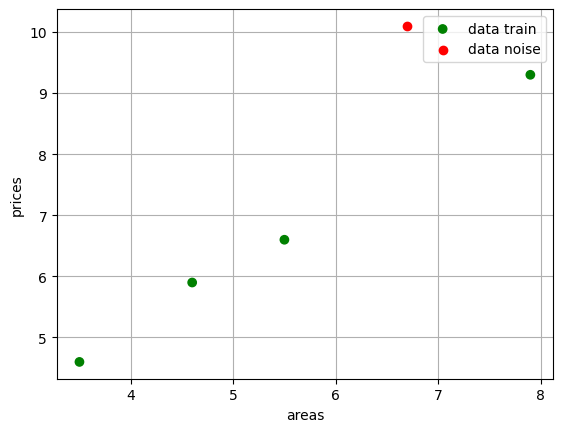

In [120]:
# Biểu diễn dữ liệu có nhiễu
plt.scatter(data_noise.iloc[:-1,:-1],data_noise.iloc[:-1,-1],c=['g','g','g','g'],label = 'data train')
plt.scatter(data_noise.iloc[-1,0],data_noise.iloc[-1,1],c ='r',label ='data noise')
plt.legend()
plt.grid()
plt.xlabel('areas')
plt.ylabel('prices')

**Model using Loss = MSE**

In [121]:
class LinearRegression_MSE:
  def __init__(self, lr=0.001, epochs=1000):
    self.lr = lr
    self.epochs = epochs
    self.w = None
    self.b = None
    self.Losses = []
  def predict(self,x):
    return self.b + x@self.w
  def compute_loss(self,y_pred,y):
    return (y_pred-y)**2
  def dL_dw(self,x,y_pred,y):
    return  2*x*(y_pred-y)
  def dL_db(self,y_pred,y):
    return 2*(y_pred-y)

  def fit(self,X,y):
    n_samples, n_features = X.shape
    rd = np.random.uniform(-1,1,size=n_features+1)
    self.b, self.w = rd[0], rd[1:]
    for epoch in range(self.epochs):
      Loss = []
      for i in range(n_samples):
        x_train, y_train = X[i], y[i]
        y_pred = self.predict(x_train)
        loss = self.compute_loss(y_pred,y_train)
        Loss.append(loss)
        dL_dw = self.dL_dw(x_train,y_pred,y_train)
        dL_db = self.dL_db(y_pred,y_train)
        self.w -= self.lr*dL_dw
        self.b -= self.lr*dL_db
      self.Losses.append(np.mean(Loss))
      print(f"Epoch: {epoch+1:<10}======== Loss: {self.Losses[-1]:<30} ============ w= {str(self.w):<20} ======= b= {str(self.b):<10}")

In [122]:
rg_MAE = LinearRegression_MAE(lr=0.01, epochs=500)

In [123]:
rg_MSE = LinearRegression_MSE(lr=0.01, epochs=500)

In [124]:
X = data_noise.iloc[:,:-1].values
y = data_noise.iloc[:,-1].values

In [125]:
# Huấn luyện mô hình sử dụng Loss MAE
rg_MAE.fit(X,y)

Epoch: 1         ======== Loss: 5.085887439477601              ============ w= [0.44099398]         ======= b= 0.7231085332059226
Epoch: 2         ======== Loss: 3.445403457666272              ============ w= [0.72299484]         ======= b= 0.7731087017696281
Epoch: 3         ======== Loss: 1.8049163117108094             ============ w= [1.00499667]         ======= b= 0.8231090661825115
Epoch: 4         ======== Loss: 0.6761038012814762             ============ w= [1.10700806]         ======= b= 0.8331114338399673
Epoch: 5         ======== Loss: 0.6363958080885993             ============ w= [1.1210588]          ======= b= 0.8431251801992968
Epoch: 6         ======== Loss: 0.6677789334231378             ============ w= [1.06509151]         ======= b= 0.833131779168464
Epoch: 7         ======== Loss: 0.5875787786368839             ============ w= [1.07512142]         ======= b= 0.8231369337536074
Epoch: 8         ======== Loss: 0.6472413713108619             ============ w= [1.08917638]

In [126]:
# Huấn luyện mô hình sử dụng Loss = MSE
rg_MSE.fit(X,y)

Epoch: 1         ======== Loss: 6.114142746850641              ============ w= [1.41506452]         ======= b= 0.4653392651683311
Epoch: 2         ======== Loss: 2.1221182951081117             ============ w= [1.4096199]          ======= b= 0.47983223996751434
Epoch: 3         ======== Loss: 2.0940891708966425             ============ w= [1.40738871]         ======= b= 0.49455444073068505
Epoch: 4         ======== Loss: 2.0920297195150193             ============ w= [1.40516288]         ======= b= 0.5091688272669666
Epoch: 5         ======== Loss: 2.08994051872548               ============ w= [1.40295321]         ======= b= 0.5236773237752355
Epoch: 6         ======== Loss: 2.08790853143879               ============ w= [1.40075955]         ======= b= 0.5380806936252387
Epoch: 7         ======== Loss: 2.0859324426085863             ============ w= [1.39858179]         ======= b= 0.5523796985641009
Epoch: 8         ======== Loss: 2.0840112536641278             ============ w= [1.396419

Text(0, 0.5, 'prices')

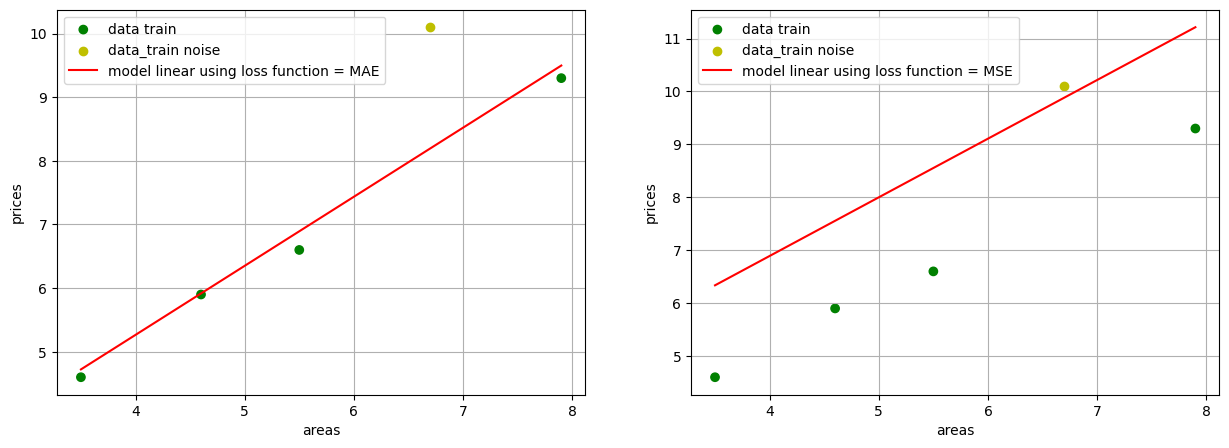

In [127]:
# So sánh hai mô hình
x_plot = np.arange(3.5,8,0.1)
plt.figure(figsize=(15,5))
# model using loss MAE
plt.subplot(1,2,1)
plt.scatter(data_noise.iloc[:-1,:-1],data_noise.iloc[:-1,-1],c=['g','g','g','g'],label = 'data train')
plt.scatter(data_noise.iloc[-1,0],data_noise.iloc[-1,1],c ='y',label ='data_train noise')
y = rg_MAE.b + rg_MAE.w*x_plot
plt.plot(x_plot,y,'r',label = 'model linear using loss function = MAE')
plt.legend()
plt.grid()
plt.xlabel('areas')
plt.ylabel('prices')

# model using loss MSE
plt.subplot(1,2,2)
plt.scatter(data_noise.iloc[:-1,:-1],data_noise.iloc[:-1,-1],c=['g','g','g','g'],label = 'data train')
plt.scatter(data_noise.iloc[-1,0],data_noise.iloc[-1,1],c ='y',label ='data_train noise')
y = rg_MSE.b + rg_MSE.w*x_plot
plt.plot(x_plot,y,'r',label = 'model linear using loss function = MSE')
plt.legend()
plt.grid()
plt.xlabel('areas')
plt.ylabel('prices')

In [128]:
import sys

In [129]:
# Max float can be display
sys.float_info.max

1.7976931348623157e+308

In [130]:
# Min float can be display
sys.float_info.min

2.2250738585072014e-308

# **Data Normalization**

In [131]:
FILE_PATH = '/content/drive/MyDrive/AIO 2024/Module_4/Week 2/T4/Data/advertising.csv'

In [132]:
class LinearRegression_MSE:
  def __init__(self, lr=0.001, epochs=1000):
    self.lr = lr
    self.epochs = epochs
    self.w = None
    self.b = None
    self.Losses = []
  def predict(self,x):
    return self.b + x@self.w
  def compute_loss(self,y_pred,y):
    return (y_pred-y)**2
  def dL_dw(self,x,y_pred,y):
    return  2*x*(y_pred-y)
  def dL_db(self,y_pred,y):
    return 2*(y_pred-y)

  def fit(self,X,y):
    n_samples, n_features = X.shape
    rd = np.random.uniform(-1,1,size=n_features+1)
    self.b, self.w = rd[0], rd[1:]
    data_train = np.concatenate((X,y.reshape(-1,1)),axis=1)
    for epoch in range(self.epochs):
      np.random.shuffle(data_train)
      Loss = []
      for i in range(n_samples):
        sample = data_train[i]
        x_train, y_train = sample[:-1],sample[-1]
        y_pred = self.predict(x_train)
        loss = self.compute_loss(y_pred,y_train)
        Loss.append(loss)
        dL_dw = self.dL_dw(x_train,y_pred,y_train)
        dL_db = self.dL_db(y_pred,y_train)
        self.w -= self.lr*dL_dw
        self.b -= self.lr*dL_db
      self.Losses.append(np.mean(Loss))
      print(f"Epoch: {epoch+1:<10}======== Loss: {self.Losses[-1]:<30} ============ w= {str(self.w):<20} ======= b= {str(self.b):<10}")

In [133]:
df = pd.read_csv(FILE_PATH)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [134]:
# Lấy thông tin cơ bản của bộ dữ liệu
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


**TH1: Nếu không chuẩn hóa DL và dùng tham số mặc định lr = 0.01**

In [135]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [136]:
rg = LinearRegression_MSE(lr=0.01, epochs=10)

In [137]:
# Huấn luyện mô hình
rg.fit(X,y)

Epoch: 1         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 2         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 3         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 4         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 5         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 6         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 7         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 8         ======== Loss: nan                            ============ w= [nan nan nan]        ======= b= nan       
Epoch: 9         =======

/tmp/ipython-input-3233398855.py:11: RuntimeWarning: overflow encountered in scalar power
  return (y_pred-y)**2
/tmp/ipython-input-3233398855.py:13: RuntimeWarning: overflow encountered in multiply
  return  2*x*(y_pred-y)
/tmp/ipython-input-3233398855.py:33: RuntimeWarning: invalid value encountered in subtract
  self.w -= self.lr*dL_dw


**=> Khi chuẩn hóa DL mô hình có thể bị overflow**

In [138]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [139]:
# Tiến hành chuẩn hóa DL
Scaler = MinMaxScaler()
X = Scaler.fit_transform(X)
X

array([[0.77578627, 0.76209677, 0.60598065],
       [0.1481231 , 0.79233871, 0.39401935],
       [0.0557998 , 0.92540323, 0.60686016],
       [0.50997633, 0.83266129, 0.51187335],
       [0.60906324, 0.21774194, 0.51099384],
       [0.02705445, 0.9858871 , 0.65699208],
       [0.19208657, 0.66129032, 0.20404573],
       [0.4041258 , 0.39516129, 0.09938434],
       [0.02671627, 0.04233871, 0.00615655],
       [0.67331755, 0.05241935, 0.18381706],
       [0.2211701 , 0.11693548, 0.21020229],
       [0.72370646, 0.48387097, 0.03254178],
       [0.07811972, 0.70766129, 0.5769569 ],
       [0.32735881, 0.15322581, 0.06068602],
       [0.68785932, 0.66330645, 0.40193492],
       [0.65843761, 0.96169355, 0.46262093],
       [0.22691917, 0.73790323, 1.        ],
       [0.94927291, 0.7983871 , 0.48812665],
       [0.2316537 , 0.41330645, 0.15831135],
       [0.49577274, 0.48185484, 0.16534741],
       [0.73621914, 0.55846774, 0.46701847],
       [0.80047345, 0.10282258, 0.20404573],
       [0.

**TH2: Mô hình sau khi đã chuẩn hóa DL**

In [140]:
rg = LinearRegression_MSE(lr=0.01, epochs=100)

In [141]:
rg.fit(X,y)

Epoch: 1         ======== Loss: 28.380642709923073             ============ w= [8.33749253 5.25650058 2.46156903] ======= b= 8.633017513762821
Epoch: 2         ======== Loss: 7.020727331323925              ============ w= [9.99139397 4.68091201 1.92364876] ======= b= 7.300454953360159
Epoch: 3         ======== Loss: 5.290657571636661              ============ w= [11.48385994  4.61583851  1.64246986] ======= b= 6.7616548371093055
Epoch: 4         ======== Loss: 4.228478826019035              ============ w= [12.6307078   4.62355091  1.43586295] ======= b= 6.3870662578854525
Epoch: 5         ======== Loss: 3.6297219072334634             ============ w= [13.4622628   4.65697041  1.22415488] ======= b= 6.03854927569645
Epoch: 6         ======== Loss: 3.2935105834747604             ============ w= [14.08425622  4.65906938  1.04871946] ======= b= 5.719383249833352
Epoch: 7         ======== Loss: 3.0299848018681748             ============ w= [14.56063938  4.76675602  0.93276091] ======= b= 5

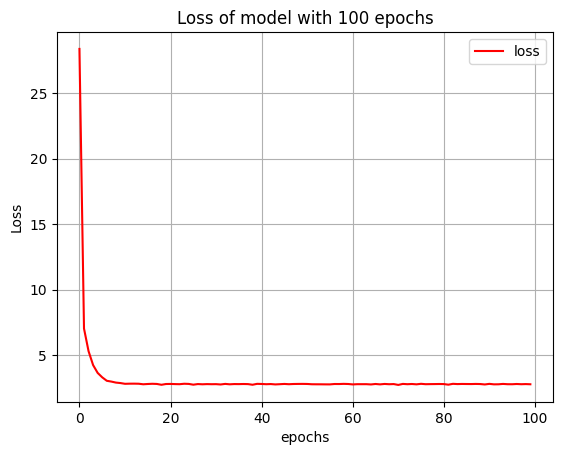

In [142]:
# Vẽ Loss của model
plt.title(f"Loss of model with {rg.epochs} epochs")
plt.plot(rg.Losses,c='r',label = 'loss')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()